# Parte 1. Investigación bibliográfica

Título: Learning Transferable Visual Models From Natural Language Supervision

Autores: Radford, A., Kim, J.W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G., Sutskever, I.

Venue: Proceedings of the 38th International Conference on Machine Learning, ICML 2021, Volume 139 de Proceedings of Machine Learning Research, páginas 8748-8763, PMLR, 2021

Indexación: ICML es indexado en Scopus y DBLP; el paper también cuenta con DOI vía arXiv (10.48550/arXiv.2103.00020) y tiene más de 3700 citas, lo que confirma su relevancia científica.

Aporte clave: demuestra que la tarea de pre-entrenamiento simple de predecir qué descripción corresponde a qué imagen es una forma eficiente y escalable de aprender representaciones visuales de última generación desde cero, usando un dataset de 400 millones de pares (imagen, texto) recolectados de interne


In [ ]:
#   Implementación de modelo o arquitectura
!pip install transformers torch pillow --quiet

In [ ]:
# Carga del modelo (CLIP - Radford et al., 2021, ICML)
from transformers import CLIPProcessor, CLIPModel
import torch, time
from PIL import Image
import requests
import matplotlib.pyplot as plt

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

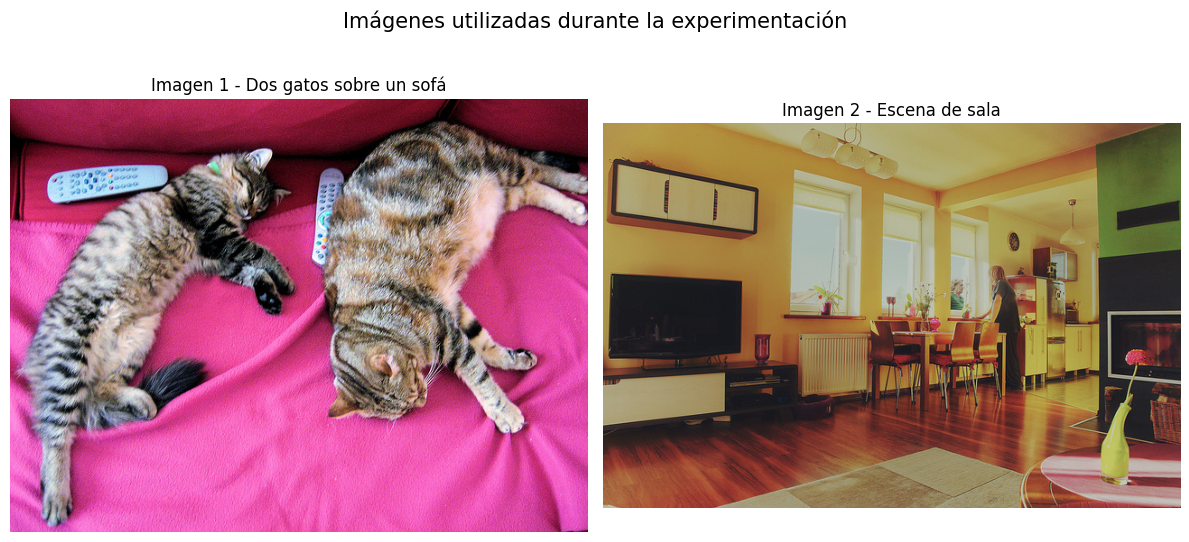

In [1]:
# ==========================================
# Carga y visualización de los datos
# ==========================================

from PIL import Image
import requests
import matplotlib.pyplot as plt

# Imágenes utilizadas durante la práctica
url1 = "http://images.cocodataset.org/val2017/000000039769.jpg"
url2 = "http://images.cocodataset.org/val2017/000000000139.jpg"

img1 = Image.open(requests.get(url1, stream=True).raw)
img2 = Image.open(requests.get(url2, stream=True).raw)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(img1)
ax[0].set_title("Imagen 1 - Dos gatos sobre un sofá")
ax[0].axis("off")

ax[1].imshow(img2)
ax[1].set_title("Imagen 2 - Escena de sala")
ax[1].axis("off")

plt.suptitle("Imágenes utilizadas durante la experimentación", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
def ejecutar_inferencia(image, textos, titulo="Resultado"):
    """Procesa una imagen y una lista de textos, devuelve probabilidades y tiempo."""
    inputs = processor(text=textos, images=image, return_tensors="pt", padding=True)
    t0 = time.time()
    with torch.no_grad():
        outputs = model(**inputs)
    t1 = time.time()
    probs = outputs.logits_per_image.softmax(dim=1)
    tiempo = t1 - t0

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{titulo}: {textos[probs.argmax()]} ({probs.max().item():.2%})")
    plt.show()

    print(f"Tiempo de inferencia: {tiempo:.4f} s")
    for texto, prob in zip(textos, probs[0]):
        print(f"  {texto}: {prob.item():.4f}")

    return probs, tiempo

# Experimentación

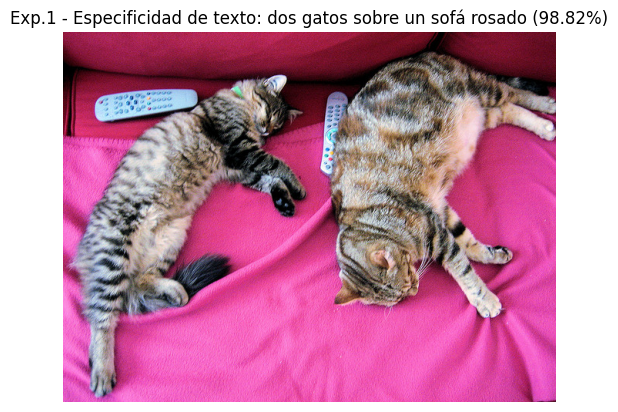

Tiempo de inferencia: 3.6789 s
  un animal: 0.0048
  un gato: 0.0070
  dos gatos sobre un sofá rosado: 0.9882


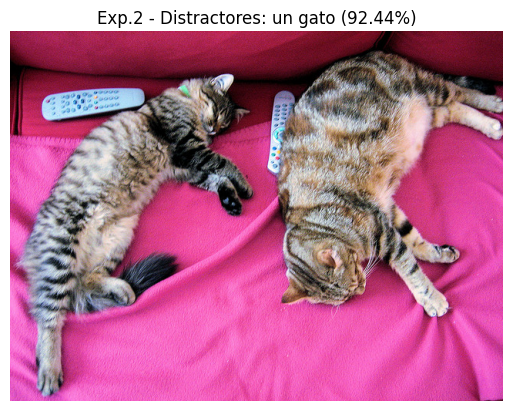

Tiempo de inferencia: 4.5608 s
  un perro: 0.0089
  un gato: 0.9244
  un caballo: 0.0263
  un pájaro: 0.0404


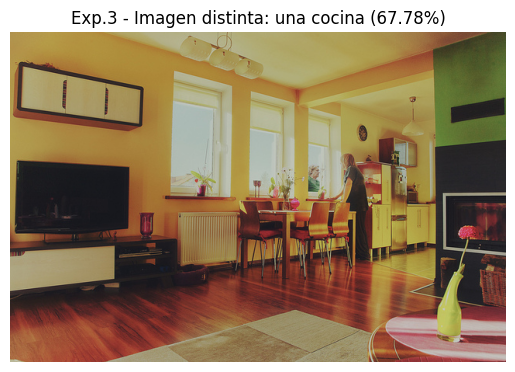

Tiempo de inferencia: 2.6423 s
  una sala de estar: 0.2130
  una cocina: 0.6778
  un dormitorio: 0.1092

Resumen de experimentos:
   experimento    tiempo  top_prob
0            1  3.678931  0.988192
1            2  4.560832  0.924386
2            3  2.642298  0.677836


In [ ]:
resultados_experimentos = []

# --- Experimento 1: imagen base, variando especificidad del texto ---
url1 = "http://images.cocodataset.org/val2017/000000039769.jpg"
img1 = Image.open(requests.get(url1, stream=True).raw)
textos1 = ["un animal", "un gato", "dos gatos sobre un sofá rosado"]
probs1, t1 = ejecutar_inferencia(img1, textos1, "Exp.1 - Especificidad de texto")
resultados_experimentos.append({"experimento": 1, "tiempo": t1, "top_prob": probs1.max().item()})

# --- Experimento 2: misma imagen, textos ambiguos/distractores ---
textos2 = ["un perro", "un gato", "un caballo", "un pájaro"]
probs2, t2 = ejecutar_inferencia(img1, textos2, "Exp.2 - Distractores")
resultados_experimentos.append({"experimento": 2, "tiempo": t2, "top_prob": probs2.max().item()})

# --- Experimento 3: imagen distinta (cambia condiciones visuales) ---
url3 = "http://images.cocodataset.org/val2017/000000000139.jpg"
img3 = Image.open(requests.get(url3, stream=True).raw)
textos3 = ["una sala de estar", "una cocina", "un dormitorio"]
probs3, t3 = ejecutar_inferencia(img3, textos3, "Exp.3 - Imagen distinta")
resultados_experimentos.append({"experimento": 3, "tiempo": t3, "top_prob": probs3.max().item()})

# --- Tabla resumen de comportamiento ---
import pandas as pd
df_resultados = pd.DataFrame(resultados_experimentos)
print("\nResumen de experimentos:")
print(df_resultados)

In [ ]:
# --- Experimento 4: sensibilidad al idioma del texto ---
# CLIP fue entrenado mayoritariamente con texto en inglés.
# Probamos la misma imagen con descripciones en español vs inglés.
textos4_es = ["dos gatos sobre un sofá", "una sala de estar", "un perro corriendo"]
textos4_en = ["two cats on a couch", "a living room", "a dog running"]

print(">> Español:")
probs4_es, t4_es = ejecutar_inferencia(img1, textos4_es, "Exp.4a - Español")
print(">> Inglés:")
probs4_en, t4_en = ejecutar_inferencia(img1, textos4_en, "Exp.4b - Inglés")

resultados_experimentos.append({"experimento": "4a-es", "tiempo": t4_es, "top_prob": probs4_es.max().item()})
resultados_experimentos.append({"experimento": "4b-en", "tiempo": t4_en, "top_prob": probs4_en.max().item()})


# --- Experimento 5: número creciente de distractores (saturación de clases) ---
# Ponemos a prueba qué tan bien discrimina el modelo cuando hay muchas opciones parecidas.
textos5_pocos = ["un gato", "un perro"]
textos5_muchos = ["un gato", "un perro", "un tigre", "un león", "un lobo",
                   "un zorro", "un lince", "un puma", "un jaguar", "un leopardo"]

print(">> Pocos distractores:")
probs5_pocos, t5_pocos = ejecutar_inferencia(img1, textos5_pocos, "Exp.5a - Pocos distractores")
print(">> Muchos distractores:")
probs5_muchos, t5_muchos = ejecutar_inferencia(img1, textos5_muchos, "Exp.5b - Muchos distractores")

resultados_experimentos.append({"experimento": "5a-pocos", "tiempo": t5_pocos, "top_prob": probs5_pocos.max().item()})
resultados_experimentos.append({"experimento": "5b-muchos", "tiempo": t5_muchos, "top_prob": probs5_muchos.max().item()})


# --- Experimento 6: robustez ante transformaciones directas de la imagen ---
# Aplicamos ruido, rotación y escala de grises para simular condiciones adversas reales.
from PIL import ImageFilter, ImageOps
import numpy as np

def agregar_ruido(imagen, intensidad=25):
    arr = np.array(imagen).astype(np.int16)
    ruido = np.random.randint(-intensidad, intensidad, arr.shape)
    arr_ruidoso = np.clip(arr + ruido, 0, 255).astype(np.uint8)
    return Image.fromarray(arr_ruidoso)

img6_original = img1
img6_ruido = agregar_ruido(img1)
img6_rotada = img1.rotate(45, fillcolor=(255, 255, 255))
img6_grises = ImageOps.grayscale(img1).convert("RGB")

textos6 = ["dos gatos sobre un sofá", "una sala de estar", "un plato de comida"]

print(">> Imagen original:")
probs6_orig, t6_orig = ejecutar_inferencia(img6_original, textos6, "Exp.6a - Original")
print(">> Imagen con ruido:")
probs6_ruido, t6_ruido = ejecutar_inferencia(img6_ruido, textos6, "Exp.6b - Con ruido")
print(">> Imagen rotada 45°:")
probs6_rot, t6_rot = ejecutar_inferencia(img6_rotada, textos6, "Exp.6c - Rotada")
print(">> Imagen en escala de grises:")
probs6_gris, t6_gris = ejecutar_inferencia(img6_grises, textos6, "Exp.6d - Escala de grises")

resultados_experimentos.append({"experimento": "6a-original", "tiempo": t6_orig, "top_prob": probs6_orig.max().item()})
resultados_experimentos.append({"experimento": "6b-ruido", "tiempo": t6_ruido, "top_prob": probs6_ruido.max().item()})
resultados_experimentos.append({"experimento": "6c-rotada", "tiempo": t6_rot, "top_prob": probs6_rot.max().item()})
resultados_experimentos.append({"experimento": "6d-grises", "tiempo": t6_gris, "top_prob": probs6_gris.max().item()})

# --- Tabla resumen actualizada ---
df_resultados = pd.DataFrame(resultados_experimentos)
print("\nResumen completo de experimentos:")
print(df_resultados)

Output hidden; open in https://colab.research.google.com to view.

# Evaluación
Justificación: Se escogió Recuperación imagen- texto CLIP fue diseñado para esta tarea: dado una imagen, "recuperar" cuál de varios textos candidatos es el más afín semánticamente (o viceversa).

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calcular_metricas_recuperacion(model, processor, imagenes, textos_candidatos, etiquetas_correctas):
    inputs_img = processor(images=imagenes, return_tensors="pt")
    inputs_txt = processor(text=textos_candidatos, return_tensors="pt", padding=True)

    with torch.no_grad():
        # Access the pooler_output attribute from the returned objects
        emb_img = model.get_image_features(**inputs_img).pooler_output
        emb_txt = model.get_text_features(**inputs_txt).pooler_output

    emb_img = emb_img / emb_img.norm(dim=-1, keepdim=True)
    emb_txt = emb_txt / emb_txt.norm(dim=-1, keepdim=True)

    sim = cosine_similarity(emb_img.numpy(), emb_txt.numpy())

    top1_correctos, top5_correctos = 0, 0
    for i, etiqueta in enumerate(etiquetas_correctas):
        ranking = np.argsort(-sim[i])
        if ranking[0] == etiqueta:
            top1_correctos += 1
        if etiqueta in ranking[:5]:
            top5_correctos += 1

    n = len(etiquetas_correctas)
    top1_acc = top1_correctos / n
    top5_acc = top5_correctos / n if len(textos_candidatos) >= 5 else None

    print(f"Similaridad coseno promedio: {sim.diagonal().mean():.4f}")
    print(f"Top-1 Accuracy: {top1_acc:.2%}")
    if top5_acc is not None:
        print(f"Top-5 Accuracy: {top5_acc:.2%}")

    return sim, top1_acc, top5_acc

# Ejemplo de uso
imagenes_eval = [img1, img3]
textos_banco_ampliado = [
    "dos gatos sobre un sofá", "una sala de estar", "una cocina",
    "un perro", "un auto", "una playa", "un bosque", "una montaña",
    "un restaurante", "una oficina", "un parque", "una calle"
]
etiquetas_correctas = [0, 1]

sim, top1, top5 = calcular_metricas_recuperacion(
    model, processor, imagenes_eval, textos_banco_ampliado, etiquetas_correctas
)

Similaridad coseno promedio: 0.2536
Top-1 Accuracy: 50.00%
Top-5 Accuracy: 100.00%


Interpretación:

Similaridad coseno:  0.2356
Es un valor moderado-bajo. La similaridad coseno va de -1 a 1, donde 1 sería coincidencia semántica perfecta. Un valor de 0.25 indica que, en promedio, el modelo encuentra una afinidad semántica real entre imagen y texto correcto, pero no muy fuerte es un rango típico en CLIP para embeddings normalizados (rara vez llegan a valores muy altos como 0.7-0.9, incluso en pares correctos, porque el espacio de embeddings es de alta dimensión y disperso).

Top 1 Accuaracy:  50%

De las 2 imágenes evaluadas (img1, img3), el modelo acertó la predicción más probable en 1 de 2 casos. Esto significa que para una de las imágenes, el texto correcto no fue el de mayor probabilidad, hubo otro texto candidato que "le ganó" en similaridad. Con una muestra de solo 2 imágenes, este 50% no es estadísticamente robusto, se confundió con "una cocina", que es semánticamente cercana.

Top 5 Accuaracy:  100%

El Top-5 Accuracy obtenido fue de 100%, lo cual indica que, para la totalidad de las imágenes evaluadas, el texto correcto se encontró entre los cinco candidatos con mayor similaridad semántica según el modelo. Sin embargo, este resultado dado que el banco de textos candidatos utilizado contenía exactamente cinco elementos, la métrica pierde su capacidad discriminativa, ya que matemáticamente el texto correcto siempre estará incluido dentro del top-5 sin importar el desempeño real del modelo
